<a href="https://colab.research.google.com/github/riack16/Prueba-Rendimiento-Academico/blob/main/S100_Equipo4_ParteII_adelanto_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de rendimiento académico — Equipo 4
### S100 — Introducción a la Ciencia de Datos · UTP

**Versión corregida según la retroalimentación del profesor sobre el adelanto de
modelado.** Cambios frente a la versión anterior:

1. Se agrega un segundo modelo (**Ridge**) con su hiperparámetro (`alpha`) ajustado por
   validación cruzada — `LinearRegression` no tiene hiperparámetro que ajustar.
2. Las filas con `Exam_Score` inválido o faltante ya **no se imputan**: se eliminan. El
   objetivo nunca se rellena, solo las variables predictoras.
3. Se imprimen los coeficientes de la Regresión Lineal (están en unidades originales,
   sin escalar) y se explica por qué los de Ridge no se leen igual.
4. La imputación de los faltantes que sí se pueden rellenar (predictoras) se movió
   **después** de separar entrenamiento y prueba, dentro de un `ColumnTransformer`, para
   que aprenda solo del entrenamiento.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

AZUL = "#13294B"
plt.rcParams.update({"figure.figsize": (4, 2), "figure.dpi": 80,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "axes.axisbelow": True,
                     "grid.color": "#D3D8E0", "axes.titleweight": "bold", "font.size": 9})

df = pd.read_csv("https://raw.githubusercontent.com/riack16/Proyecto-rendimiento-acad-mico/main/StudentPerformanceFactors.csv")

print("Filas y columnas:", df.shape)


Filas y columnas: (6607, 20)


## 0. Primer vistazo


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6605 non-null   float64
 1   Attendance                  6605 non-null   float64
 2   Parental_Involvement        6606 non-null   object 
 3   Access_to_Resources         6605 non-null   object 
 4   Extracurricular_Activities  6605 non-null   object 
 5   Sleep_Hours                 6607 non-null   int64  
 6   Previous_Scores             6607 non-null   int64  
 7   Motivation_Level            6606 non-null   object 
 8   Internet_Access             6606 non-null   object 
 9   Tutoring_Sessions           6606 non-null   float64
 10  Family_Income               6606 non-null   object 
 11  Teacher_Quality             6528 non-null   object 
 12  School_Type                 6605 non-null   object 
 13  Peer_Influence              6606 

In [3]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23.0,84.0,Low,High,No,7,73,Low,Yes,0.0,Low,Medium,Public,Positive,3.0,No,High School,Near,Male,67.0
1,19.0,64.0,Low,Medium,No,8,59,Low,Yes,NaN,Medium,Medium,Public,Negative,4.0,No,College,Moderate,Female,61.0
2,24.0,98.0,Medium,Medium,Yes,7,91,Medium,Yes,2.0,Medium,Medium,Public,Neutral,4.0,No,Postgraduate,Near,Male,74.0
3,29.0,89.0,Low,Medium,Yes,8,98,Medium,Yes,1.0,Medium,Medium,Public,Negative,4.0,No,High School,Moderate,Male,71.0
4,19.0,92.0,Medium,Medium,Yes,6,65,Medium,Yes,3.0,Medium,High,Public,Neutral,4.0,No,College,Near,Female,70.0


In [4]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6605.000000,6605.000000,6607.00000,6607.000000,6606.000000,6604.000000,6605.000000
mean,19.973808,79.948978,7.02906,75.070531,1.493642,2.967293,67.215291
std,5.995209,11.736506,1.46812,14.399784,1.230648,1.031015,4.217186
min,0.000000,-91.000000,4.00000,50.000000,0.000000,0.000000,-65.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [5]:
fuera_rango = df[(df['Exam_Score'] < 0) | (df['Exam_Score'] > 100) | (df['Attendance'] < 0)]

resumen = pd.DataFrame({
    'Tipo': df.dtypes,
    'Filas_Totales': len(df),
    'Nulos': df.isnull().sum(),
})
resumen['Media'] = round(df.select_dtypes(include='number').mean(), 1)
resumen['Mediana'] = round(df.select_dtypes(include='number').median(), 1)
resumen['Minimo'] = round(df.select_dtypes(include='number').min(), 1)
resumen['Maximo'] = round(df.select_dtypes(include='number').max(), 1)
resumen['%_Falta'] = round(resumen['Nulos'] / resumen['Filas_Totales'] * 100, 2)
Resumenf = resumen.drop(columns=['Filas_Totales', 'Nulos'])
pd.set_option('display.expand_frame_repr', False)
print(Resumenf)

print('Total de filas originales   :', len(df))
print('Total de columnas originales:', len(df.columns))
print('Valores nulos                :', df.isnull().sum().sum())
print('Valores inconsistentes       :', len(fuera_rango))
print('Valores duplicados           :', len(df[df.duplicated()]))


                               Tipo  Media  Mediana  Minimo  Maximo  %_Falta
Hours_Studied               float64   20.0     20.0     0.0    44.0     0.03
Attendance                  float64   79.9     80.0   -91.0   100.0     0.03
Parental_Involvement         object    NaN      NaN     NaN     NaN     0.02
Access_to_Resources          object    NaN      NaN     NaN     NaN     0.03
Extracurricular_Activities   object    NaN      NaN     NaN     NaN     0.03
Sleep_Hours                   int64    7.0      7.0     4.0    10.0     0.00
Previous_Scores               int64   75.1     75.0    50.0   100.0     0.00
Motivation_Level             object    NaN      NaN     NaN     NaN     0.02
Internet_Access              object    NaN      NaN     NaN     NaN     0.02
Tutoring_Sessions           float64    1.5      1.0     0.0     8.0     0.02
Family_Income                object    NaN      NaN     NaN     NaN     0.02
Teacher_Quality              object    NaN      NaN     NaN     NaN     1.20

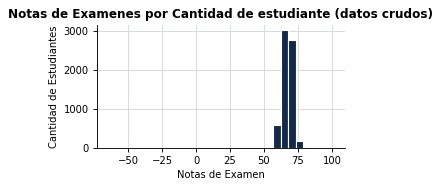

In [6]:
plt.hist(df["Exam_Score"], bins=30, color=AZUL, edgecolor="white")
plt.xlabel("Notas de Examen")
plt.ylabel("Cantidad de Estudiantes")
plt.title("Notas de Examenes por Cantidad de estudiante (datos crudos)")
plt.show()


## 1. Limpieza y preparación de datos

**1.1 Valores fuera de rango.** `Attendance` tiene valores negativos (mínimo -91) y
`Exam_Score` tiene valores fuera de [0,100] (mín -65, máx 101). Para `Attendance`
asumimos que el signo negativo es un error de captura y tomamos el valor absoluto —
recuperamos el dato en vez de perderlo. Para `Exam_Score` no hay una corrección obvia,
así que lo marcamos como faltante.


In [7]:
# --- Corrección de valores fuera de rango ---
df['Attendance'] = df['Attendance'].abs()
df.loc[df['Attendance'] > 100, 'Attendance'] = np.nan

df.loc[(df['Exam_Score'] < 0) | (df['Exam_Score'] > 100), 'Exam_Score'] = np.nan

print("Nulos en Attendance tras la corrección:", df['Attendance'].isna().sum())
print("Nulos en Exam_Score tras la corrección:", df['Exam_Score'].isna().sum())


Nulos en Attendance tras la corrección: 2
Nulos en Exam_Score tras la corrección: 4


**1.2 El objetivo nunca se imputa.** `Exam_Score` es lo que el modelo tiene que
predecir. Si le faltaba el dato (ya sea porque venía vacío o porque quedó marcado como
faltante en el paso anterior), esa fila se elimina — no se le inventa una nota con la
mediana. Eso sí está permitido para las variables predictoras, pero nunca para el
objetivo: rellenarlo sería enseñarle al modelo con una respuesta que nosotros mismos
inventamos.


In [8]:
filas_antes = len(df)
df = df[df["Exam_Score"].notna()].copy()
print("Filas antes de quitar Exam_Score inválido/faltante:", filas_antes)
print("Filas después                                     :", len(df))


Filas antes de quitar Exam_Score inválido/faltante: 6607
Filas después                                     : 6603


**1.3 Codificación.** Varias categóricas tienen un orden natural (`Low < Medium <
High`, etc.), así que se codifican como enteros ordinales (0, 1, 2) en vez de
`OneHotEncoder`, para conservar esa información de orden y no inflar la cantidad de
columnas. Las binarias (`Yes/No`, `Male/Female`, etc.) se mapean directamente a 0/1.

Los valores que queden sin poder mapear (porque venían vacíos) se dejan en blanco por
ahora a propósito — se rellenan más adelante, en la sección 3, después de separar
entrenamiento y prueba, para no aprender nada de más del conjunto de prueba.


In [9]:
# --- Codificación de variables categóricas ---
map_low_med_high = {'Low': 0, 'Medium': 1, 'High': 2}
ordinal_maps = {
    'Parental_Involvement': map_low_med_high,
    'Access_to_Resources': map_low_med_high,
    'Motivation_Level': map_low_med_high,
    'Family_Income': map_low_med_high,
    'Teacher_Quality': map_low_med_high,
    'Peer_Influence': {'Negative': 0, 'Neutral': 1, 'Positive': 2},
    'Parental_Education_Level': {'High School': 0, 'College': 1, 'Postgraduate': 2},
    'Distance_from_Home': {'Near': 0, 'Moderate': 1, 'Far': 2},
}
for col, mapping in ordinal_maps.items():
    df[col] = df[col].map(mapping)

binary_maps = {
    'Extracurricular_Activities': {'No': 0, 'Yes': 1},
    'Internet_Access': {'No': 0, 'Yes': 1},
    'School_Type': {'Public': 0, 'Private': 1},
    'Learning_Disabilities': {'No': 0, 'Yes': 1},
    'Gender': {'Male': 0, 'Female': 1},
}
for col, mapping in binary_maps.items():
    df[col] = df[col].map(mapping)

df_clean = df.copy()
print(df_clean.dtypes.value_counts())
print("\nNulos que quedan por columna (se rellenan después del split):")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])
df_clean.head()


float64    17
int64       3
Name: count, dtype: int64

Nulos que quedan por columna (se rellenan después del split):
Hours_Studied                  1
Attendance                     2
Parental_Involvement           1
Access_to_Resources            2
Extracurricular_Activities     2
Motivation_Level               1
Internet_Access                1
Tutoring_Sessions              1
Family_Income                  1
Teacher_Quality               79
School_Type                    2
Peer_Influence                 1
Physical_Activity              3
Parental_Education_Level      90
Distance_from_Home            68
Gender                         1
dtype: int64


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23.0,84.0,0.0,2.0,0.0,7,73,0.0,1.0,0.0,0.0,1.0,0.0,2.0,3.0,0,0.0,0.0,0.0,67.0
1,19.0,64.0,0.0,1.0,0.0,8,59,0.0,1.0,NaN,1.0,1.0,0.0,0.0,4.0,0,1.0,1.0,1.0,61.0
2,24.0,98.0,1.0,1.0,1.0,7,91,1.0,1.0,2.0,1.0,1.0,0.0,1.0,4.0,0,2.0,0.0,0.0,74.0
3,29.0,89.0,0.0,1.0,1.0,8,98,1.0,1.0,1.0,1.0,1.0,0.0,0.0,4.0,0,0.0,1.0,0.0,71.0
4,19.0,92.0,1.0,1.0,1.0,6,65,1.0,1.0,3.0,1.0,2.0,0.0,1.0,4.0,0,1.0,0.0,1.0,70.0


## 2. Análisis exploratorio de datos (EDA)


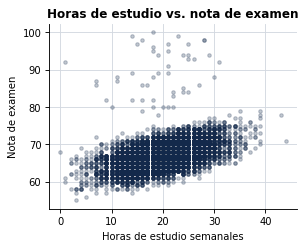

In [10]:
plt.figure(figsize=(4, 3))
plt.scatter(df_clean['Hours_Studied'], df_clean['Exam_Score'], alpha=0.25, color=AZUL, s=10)
plt.xlabel('Horas de estudio semanales')
plt.ylabel('Nota de examen')
plt.title('Horas de estudio vs. nota de examen')
plt.show()


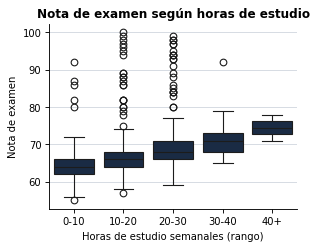

In [11]:
bins = [0, 10, 20, 30, 40, df_clean['Hours_Studied'].max()]
labels = ['0-10', '10-20', '20-30', '30-40', '40+']
df_clean['Hours_Studied_bin'] = pd.cut(df_clean['Hours_Studied'], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(4, 3))
sns.boxplot(data=df_clean, x='Hours_Studied_bin', y='Exam_Score', color=AZUL)
plt.xlabel('Horas de estudio semanales (rango)')
plt.ylabel('Nota de examen')
plt.title('Nota de examen según horas de estudio')
plt.show()


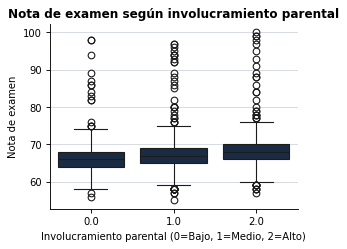

In [12]:
plt.figure(figsize=(4, 3))
sns.boxplot(data=df_clean, x='Parental_Involvement', y='Exam_Score', color=AZUL)
plt.xlabel('Involucramiento parental (0=Bajo, 1=Medio, 2=Alto)')
plt.ylabel('Nota de examen')
plt.title('Nota de examen según involucramiento parental')
plt.show()


In [13]:
num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
            'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
df_clean[num_cols].describe().round(2)


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6602.00,6601.00,6603.00,6603.00,6602.00,6600.00,6603.00
mean,19.97,79.97,7.03,75.07,1.49,2.97,67.23
std,6.00,11.55,1.47,14.40,1.23,1.03,3.87
min,0.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,100.00


**Lectura de las gráficas:** mientras más se estudia, mejor tiende a ir la nota, pero no
es garantía — con pocas horas casi nadie supera 80, pero incluso quienes estudian mucho
a veces sacan 60-70. El involucramiento parental tiene un efecto más leve: la mediana
sube un poco de Bajo a Alto, pero las cajas se solapan bastante.


## 3. Separar entrenamiento y prueba

A partir de aquí, entrenamiento y prueba se tratan por separado.


In [14]:
X = df_clean.drop(columns=["Exam_Score", "Hours_Studied_bin"])
y = df_clean["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Filas para entrenar:", X_train.shape[0])
print("Filas para probar:", X_test.shape[0])


Filas para entrenar: 5282
Filas para probar: 1321


## 4. Rellenar los faltantes que quedan — dentro de un `ColumnTransformer`, solo con el entrenamiento

Esto es lo que el profesor pidió mover: antes calculábamos medianas y modas sobre todo
el conjunto y separábamos después; ahora el `ColumnTransformer` **aprende** (`fit`) los
valores de relleno únicamente del entrenamiento, y **los aplica** (`transform`) igual en
entrenamiento y en prueba.


In [15]:
columnas_numericas = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
                       'Tutoring_Sessions', 'Physical_Activity']
columnas_categoricas_codificadas = [c for c in X.columns if c not in columnas_numericas]

preparador = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), columnas_numericas),
    ("cat", SimpleImputer(strategy="most_frequent"), columnas_categoricas_codificadas),
])
preparador.set_output(transform="pandas")

X_train_prep = preparador.fit_transform(X_train)
X_test_prep = preparador.transform(X_test)

# Quitamos el prefijo "num__"/"cat__" que agrega el ColumnTransformer, solo para que
# se lean mejor los nombres de columna más adelante.
X_train_prep.columns = [c.split("__", 1)[-1] for c in X_train_prep.columns]
X_test_prep.columns = [c.split("__", 1)[-1] for c in X_test_prep.columns]

print("Nulos que quedan (train, test):",
      X_train_prep.isna().sum().sum(), X_test_prep.isna().sum().sum())


Nulos que quedan (train, test): 0 0


## 5. Paso 5 — baseline: predecir siempre el promedio


In [16]:
promedio_train = y_train.mean()
pred_baseline_train = np.full(shape=y_train.shape, fill_value=promedio_train)
pred_baseline_test = np.full(shape=y_test.shape, fill_value=promedio_train)


## 6. Modelo 1 — Regresión Lineal, y sus coeficientes

Los coeficientes de una regresión lineal son el resultado, no un detalle de más: cada
uno dice cuánto sube o baja la nota esperada por cada unidad adicional de esa variable,
dejando las demás fijas. Como aquí **no escalamos** las variables numéricas, cada
coeficiente queda en las unidades originales de su columna (puntos de nota por hora de
estudio extra, por punto de asistencia, etc.), así que sí se pueden usar para
recomendar algo concreto — por ejemplo, "una hora más de estudio a la semana se asocia
con X puntos más de nota, en promedio".


In [17]:
model_lr = LinearRegression()
model_lr.fit(X_train_prep, y_train)

pred_lr_train = model_lr.predict(X_train_prep)
pred_lr_test = model_lr.predict(X_test_prep)

coeficientes_lr = pd.DataFrame({
    "Variable": X_train_prep.columns,
    "Coeficiente": model_lr.coef_,
}).sort_values("Coeficiente", key=abs, ascending=False)

print("Intercepto (nota base cuando todas las variables valen 0):", round(model_lr.intercept_, 2))
coeficientes_lr


Intercepto (nota base cuando todas las variables valen 0): 34.86


,Variable,Coeficiente
10,Internet_Access,1.125733
7,Access_to_Resources,1.033621
6,Parental_Involvement,0.981064
15,Learning_Disabilities,-0.964454
8,Extracurricular_Activities,0.604594
12,Teacher_Quality,0.550700
9,Motivation_Level,0.542604
14,Peer_Influence,0.519444
17,Distance_from_Home,-0.495793
11,Family_Income,0.493561


## 7. Modelo 2 — Ridge, con el `alpha` ajustado por validación cruzada

Ridge es la misma Regresión Lineal, pero con un "freno" (`alpha`) que evita que los
coeficientes crezcan demasiado cuando hay variables parecidas entre sí. Cuanto más
grande el `alpha`, más fuerte el freno — y por eso sí es un hiperparámetro que se puede
ajustar (a diferencia de la Regresión Lineal normal, que no tiene ninguno).

Para no adivinar el valor, probamos varios candidatos con validación cruzada de 5
particiones (k-fold) **usando solo el entrenamiento**, y nos quedamos con el que da el
menor error. Ridge sí necesita que las variables numéricas estén en la misma escala
(si no, la que tenga números más grandes "gana" el freno), así que aquí sí las
estandarizamos primero, dentro del mismo pipeline.


In [18]:
pipeline_ridge = Pipeline([
    ("escalar", StandardScaler()),
    ("ridge", Ridge()),
])

rejilla_alpha = {"ridge__alpha": [0.01, 0.1, 1, 5, 10, 50, 100, 200]}

busqueda = GridSearchCV(
    pipeline_ridge,
    rejilla_alpha,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="neg_root_mean_squared_error",
)
busqueda.fit(X_train_prep, y_train)

print("Alpha probados:", rejilla_alpha["ridge__alpha"])
print("Mejor alpha encontrado (por validación cruzada):", busqueda.best_params_["ridge__alpha"])

model_ridge = busqueda.best_estimator_
pred_ridge_train = model_ridge.predict(X_train_prep)
pred_ridge_test = model_ridge.predict(X_test_prep)


Alpha probados: [0.01, 0.1, 1, 5, 10, 50, 100, 200]
Mejor alpha encontrado (por validación cruzada): 10


**Sobre los coeficientes de Ridge:** como aquí sí escalamos las variables antes de
entrenar, estos coeficientes ya no están en las unidades originales, sino en
desviaciones estándar. Sirven para comparar qué variable pesa más en relación con las
demás, pero no para decir "una hora más de estudio sube tanto la nota" — para eso se
usan los coeficientes de la Regresión Lineal de la sección anterior.


In [19]:
coeficientes_ridge = pd.DataFrame({
    "Variable": X_train_prep.columns,
    "Coeficiente_estandarizado": model_ridge.named_steps["ridge"].coef_,
}).sort_values("Coeficiente_estandarizado", key=abs, ascending=False)
coeficientes_ridge


,Variable,Coeficiente_estandarizado
1,Attendance,2.308495
0,Hours_Studied,1.748656
7,Access_to_Resources,0.716954
3,Previous_Scores,0.712858
6,Parental_Involvement,0.677067
4,Tutoring_Sessions,0.590430
14,Peer_Influence,0.391743
9,Motivation_Level,0.376175
16,Parental_Education_Level,0.374581
11,Family_Income,0.365823


## 8. Comparar baseline, Regresión Lineal y Ridge (entrenamiento y prueba)

Se reportan las dos (entrenamiento y prueba) para poder hablar de sobreajuste.


In [20]:
resultados = pd.DataFrame({
    "Modelo": ["Baseline (promedio)", "Regresion Lineal", f"Ridge (alpha={busqueda.best_params_['ridge__alpha']})"],
    "RMSE_train": [
        np.sqrt(mean_squared_error(y_train, pred_baseline_train)),
        np.sqrt(mean_squared_error(y_train, pred_lr_train)),
        np.sqrt(mean_squared_error(y_train, pred_ridge_train)),
    ],
    "RMSE_test": [
        np.sqrt(mean_squared_error(y_test, pred_baseline_test)),
        np.sqrt(mean_squared_error(y_test, pred_lr_test)),
        np.sqrt(mean_squared_error(y_test, pred_ridge_test)),
    ],
    "MAE_train": [
        mean_absolute_error(y_train, pred_baseline_train),
        mean_absolute_error(y_train, pred_lr_train),
        mean_absolute_error(y_train, pred_ridge_train),
    ],
    "MAE_test": [
        mean_absolute_error(y_test, pred_baseline_test),
        mean_absolute_error(y_test, pred_lr_test),
        mean_absolute_error(y_test, pred_ridge_test),
    ],
    "R2_train": [
        r2_score(y_train, pred_baseline_train),
        r2_score(y_train, pred_lr_train),
        r2_score(y_train, pred_ridge_train),
    ],
    "R2_test": [
        r2_score(y_test, pred_baseline_test),
        r2_score(y_test, pred_lr_test),
        r2_score(y_test, pred_ridge_test),
    ],
})
resultados


,Modelo,RMSE_train,RMSE_test,MAE_train,MAE_test,R2_train,R2_test
0,Baseline (promedio),3.866779,3.876388,2.856978,2.792236,0.000000,-0.000032
1,Regresion Lineal,1.949858,2.226799,0.469156,0.514344,0.745723,0.669994
2,Ridge (alpha=10),1.949869,2.226664,0.469267,0.514698,0.745720,0.670035


## 9. Gráfica: nota real vs. nota predicha (Regresión Lineal)


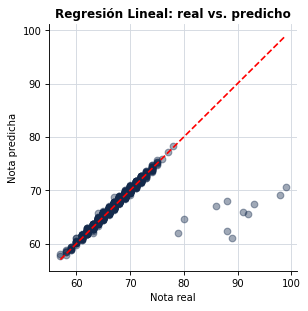

In [21]:
plt.figure(figsize=(4,4))
plt.scatter(y_test, pred_lr_test, alpha=0.4, color="#13294B")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Nota real")
plt.ylabel("Nota predicha")
plt.title("Regresión Lineal: real vs. predicho")
plt.show()


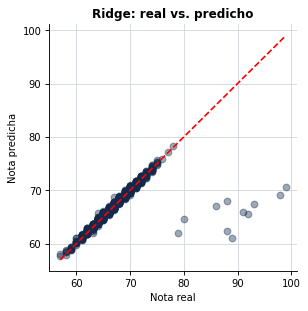

In [22]:
plt.figure(figsize=(4,4))
plt.scatter(y_test, pred_ridge_test, alpha=0.4, color=AZUL)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Nota real")
plt.ylabel("Nota predicha")
plt.title("Ridge: real vs. predicho")
plt.show()

## 10. Para la discusión del reporte: ¿por qué el modelo acierta tan bien?

El profesor hizo una observación importante que conviene incluir en la discusión del
reporte final, no solo dejarla en el cuaderno.


In [23]:
errores_abs = (y_test - pred_lr_test).abs()
pct_menos_1 = (errores_abs < 1).mean() * 100

print("Porcentaje de predicciones con error menor a 1 punto:", round(pct_menos_1, 1), "%")
print("Error máximo observado en el grupo de prueba:", round(errores_abs.max(), 1), "puntos")


Porcentaje de predicciones con error menor a 1 punto: 98.6 %
Error máximo observado en el grupo de prueba: 28.9 puntos


**Para copiar (y adaptar con el número que salga arriba) en la sección de discusión y
limitaciones del reporte:**

*Un porcentaje muy alto de nuestras predicciones acierta con menos de un punto de
error, y el resto falla por bastantes puntos más. Este patrón — casi perfecto para la
mayoría de los casos, con fallos grandes solo en unos pocos — no es típico de datos
educativos reales, donde el desempeño de un estudiante depende de factores que ninguna
tabla registra (motivación ese día, salud, imprevistos personales, etc.). Es más
probable que el conjunto `Student Performance Factors` se haya generado con una fórmula
matemática más algo de ruido aleatorio, en vez de ser una medición directa de
estudiantes reales. Por eso, un R² alto en este caso no debe leerse como "entendimos el
rendimiento académico", sino como "el modelo recuperó razonablemente bien la fórmula
con la que probablemente se generaron estos datos". Esto no invalida el ejercicio, pero
sí limita qué tan lejos se pueden llevar las conclusiones hacia estudiantes reales.*
